In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../ex02/AAPL.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df = df.dropna()
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.128348,0.128906,0.128348,0.128348,0.101073,469033600.0
1980-12-15,0.122210,0.122210,0.121652,0.121652,0.095800,175884800.0
1980-12-16,0.113281,0.113281,0.112723,0.112723,0.088768,105728000.0
1980-12-17,0.115513,0.116071,0.115513,0.115513,0.090965,86441600.0
1980-12-18,0.118862,0.119420,0.118862,0.118862,0.093603,73449600.0


In [4]:
# shift(-1) moves prices UP by one row
# so each row now shows tomorrow's price
future_returns = (df['Adj Close'].shift(-1) - df['Adj Close']) / df['Adj Close']
future_returns.name = 'Daily_futur_returns'

print(future_returns)

Date
1980-12-12   -0.052170
1980-12-15   -0.073403
1980-12-16    0.024750
1980-12-17    0.029000
1980-12-18    0.061024
                ...   
2021-01-25    0.001679
2021-01-26   -0.007684
2021-01-27   -0.034985
2021-01-28   -0.037421
2021-01-29         NaN
Name: Daily_futur_returns, Length: 10118, dtype: float64


In [5]:
np.random.seed(2712)

signal = pd.Series(
    data=np.random.randint(0, 2, len(df.index)),
    index=df.index,
    name='long_only_signal'
)

print(signal)

Date
1980-12-12    1
1980-12-15    0
1980-12-16    1
1980-12-17    1
1980-12-18    1
             ..
2021-01-25    1
2021-01-26    1
2021-01-27    1
2021-01-28    0
2021-01-29    1
Name: long_only_signal, Length: 10118, dtype: int64


In [7]:
pnl = signal * future_returns
pnl.name = 'PnL'
print(pnl)

Date
1980-12-12   -0.052170
1980-12-15   -0.000000
1980-12-16    0.024750
1980-12-17    0.029000
1980-12-18    0.061024
                ...   
2021-01-25    0.001679
2021-01-26   -0.007684
2021-01-27   -0.034985
2021-01-28   -0.000000
2021-01-29         NaN
Name: PnL, Length: 10118, dtype: float64


In [9]:
total_return = pnl.sum() / signal.sum()
print(total_return)

0.0009084942171248688


In [11]:
always_buy_signal = pd.Series(
    data=np.ones(len(df.index), dtype=int),
    index=df.index,
    name='long_only_signal'
)

always_buy_pnl = always_buy_signal * future_returns
always_buy_pnl.name = 'PnL_always_buy'

total_return_always_buy = always_buy_pnl.sum() / always_buy_signal.sum()
print(total_return_always_buy)

0.0011267019414096901


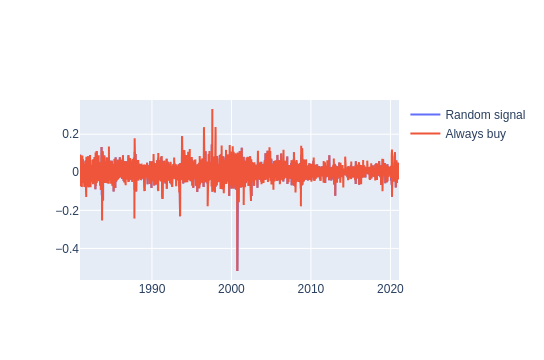

In [12]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=pnl.index, y=pnl, name='Random signal'))
fig.add_trace(go.Scatter(x=always_buy_pnl.index, y=always_buy_pnl, name='Always buy'))

fig.show()